# Импорт необходимых библиотек

In [241]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import torch
from sklearn.metrics import accuracy_score as accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Просмотр и предварительная обработка данных

Прочитаем данные, уберем ненужные признаки и превратим колонки Geography, Gender в one-hot колонки.
Также проверим сбалансированность. Имеем дело с дисбалансом классов (20/80)!


In [242]:
df = pd.read_csv("churn_modeling.csv")
print(df.head())
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df = pd.get_dummies(df, columns=['Geography', 'Gender'], dtype=int)
cols = df.columns

X = df.drop(columns=['Exited'])
y = df['Exited']
print(f'Всего объектов: {len(y)}, объектов класса 1: {np.sum(np.array(y))}')

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

# Скейлинг и добавление синтетических данных

Понятно, что нужно скейлить числовые признаки. Убедимся в этом получив экземпляры нескольких объектов.
Потом разделим данные на train/val/test в пропорции 0.64/0.16/0.2. Ну и сделаем собственно скейл данных и сразу переведем в тензор для того, чтобы наша модель смогла с ними работать.
Наши классы несбалансированы. Используем SMOTE для того, чтобы они теперь были в пропорции 50/50


In [243]:
for idx, col in enumerate(cols.drop("Exited")):
    print(f'{col}: {X.iloc[0, idx]}, {X.iloc[1, idx]}, {X.iloc[2, idx]}, {X.iloc[3, idx]}')
features_to_scale = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

CreditScore: 619, 608, 502, 699
Age: 42, 41, 42, 39
Tenure: 2, 1, 8, 1
Balance: 0.0, 83807.86, 159660.8, 0.0
NumOfProducts: 1, 1, 3, 2
HasCrCard: 1, 0, 1, 0
IsActiveMember: 1, 1, 0, 0
EstimatedSalary: 101348.88, 112542.58, 113931.57, 93826.63
Geography_France: 1, 0, 1, 1
Geography_Germany: 0, 0, 0, 0
Geography_Spain: 0, 1, 0, 0
Gender_Female: 1, 1, 1, 1
Gender_Male: 0, 0, 0, 0


In [244]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, stratify=y_train, test_size=0.2, random_state=42)
#0.64 train, 0.16 val, 0.2 test

ct = ColumnTransformer([
    ('scaler', StandardScaler(), features_to_scale)
], remainder='passthrough')

ct.fit(X_train)
X_train_scaled = torch.Tensor(ct.transform(X_train))
X_val_scaled = torch.Tensor(ct.transform(X_val))
X_test_scaled = torch.Tensor(ct.transform(X_test))

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
print(sum(y_train_balanced), len(y_train_balanced))

5096 10192


# Обучение MLP

```python
import importlib
import model
importlib.reload(model)
from model import ModelMLP
```
Этот кусочек кода нужен для того, чтобы при обновлении модели Jupyter использовал обновленную, а не старую.
В нашем случае сработал early stopping


In [245]:
import importlib
import model
importlib.reload(model)
from model import ModelMLP
model = ModelMLP(X_train_balanced.shape[1])
model.fit(X_train=X_train_balanced,
          y_train=torch.from_numpy(y_train_balanced.values.copy()).float(),
          opt_name="Adam",
          epochs=512,
          batch_size=256,
          X_val=X_val_scaled,
          y_val=torch.from_numpy(y_val.values.copy()).float(),
          lr=0.001,
          weight_decay=1e-4)

Training:  51%|█████     | 260/512 [00:35<00:34,  7.31it/s, loss=0.4624]

Early stopping at epoch 260


# Результаты модели
Построим графики лоссов для того, чтобы понять: вообще обучается ли наша модель, не переобучается ли она. В нашем случае все ок: лосс на трейне и валидационной выборке стабильно падает, модель не переобучается.

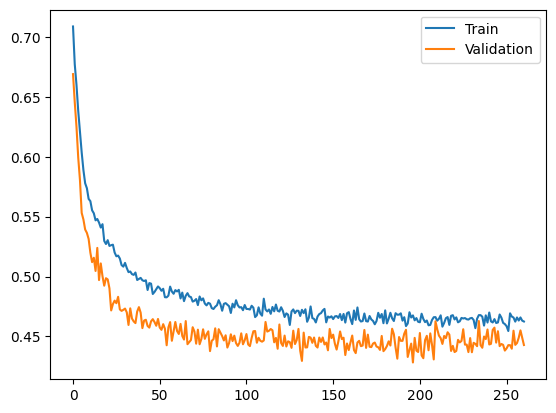

In [246]:

train_loss = model.loss_history
val_loss = model.val_loss_history
plt.plot(train_loss, label='Train')
plt.plot(val_loss, label='Validation')
plt.legend()
plt.show()    # должно быть = эпохам (если есть валидация)

 ## Основные метрики

 Оценка MLP на тестовой выборке при пороге 0.5:

In [247]:
y_pred = model.predict(X_test_scaled, threshold = 0.5).squeeze(1).numpy()
y_test = np.array(y_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1: {f1_score(y_test, y_pred):.4f}")
# Accuracy: 0.8285
# Precision: 0.5656
# Recall: 0.6781
# F1: 0.6168

Accuracy: 0.8085
Precision: 0.5213
Recall: 0.7224
F1: 0.6056


### Интерпретация

- **Accuracy 80%** — общая доля правильных ответов (с учётом дисбаланса)
- **Precision 52.2%** — из всех предсказанных ушедших только 52% действительно ушли
- **Recall 72.2%** — модель находит 72% реальных ушедших клиентов
- **F1 0.6** — гармоническое среднее precision и recall

> Модель **смещена в сторону recall** — находит большинство ушедших, но ценой ложных срабатываний. При необходимости можно повысить precision, увеличив порог классификации

# Сравнение с CatBoost и RandomForestClassifer

Перевод данных в numpy-массивы:

In [231]:
X_train_np = X_train_balanced.numpy() if hasattr(X_train_balanced, 'numpy') else X_train_balanced
y_train_np = y_train_balanced.numpy() if hasattr(y_train_balanced, 'numpy') else y_train_balanced
X_test_np = X_test_scaled.numpy() if hasattr(X_test_scaled, 'numpy') else X_test_scaled
y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test

### Обучение CatBoostClassifier

In [232]:
from catboost import CatBoostClassifier

model_gb = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    verbose=False,
    random_seed=42,
    auto_class_weights='Balanced'  # для дисбаланса
)

model_gb.fit(X_train_np, y_train_np)

y_pred_gb = model_gb.predict(X_test_np)

print(f"Accuracy: {accuracy_score(y_test_np, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test_np, y_pred_gb):.4f}")
print(f"Recall: {recall_score(y_test_np, y_pred_gb):.4f}")
print(f"F1: {f1_score(y_test_np, y_pred_gb):.4f}")

Accuracy: 0.8595
Precision: 0.6810
Recall: 0.5823
F1: 0.6278


### Обучение RandomForestClassifier

In [237]:
from sklearn.ensemble import RandomForestClassifier as RFC

model_rf = RFC(
    n_estimators=200,
    max_depth=16,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',  # для дисбаланса
    random_state=42,
    n_jobs=-1,  # использует все ядра
    verbose=False
)

model_rf.fit(X_train_np, y_train_np)

y_pred_rf = model_rf.predict(X_test_np)

# Метрики
print(f"Accuracy: {accuracy_score(y_test_np, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test_np, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test_np, y_pred_rf):.4f}")
print(f"F1: {f1_score(y_test_np, y_pred_rf):.4f}")

Accuracy: 0.8435
Precision: 0.6163
Recall: 0.6118
F1: 0.6141


## Оценка моделей

Для окончательного сравнения MLP, CatBoost и Random Forest построим **PR-кривые** (Precision-Recall) и **ROC-кривые** (Receiver Operating Characteristic).

- **ROC-AUC** показывает способность модели разделять классы в целом. Хорошее значение > 0.85.
- **PR-AUC** более информативна при дисбалансе классов (20% ушедших). Значение > 0.70 считается хорошим.

Ниже приведены кривые для всех трёх моделей на тестовой выборке.

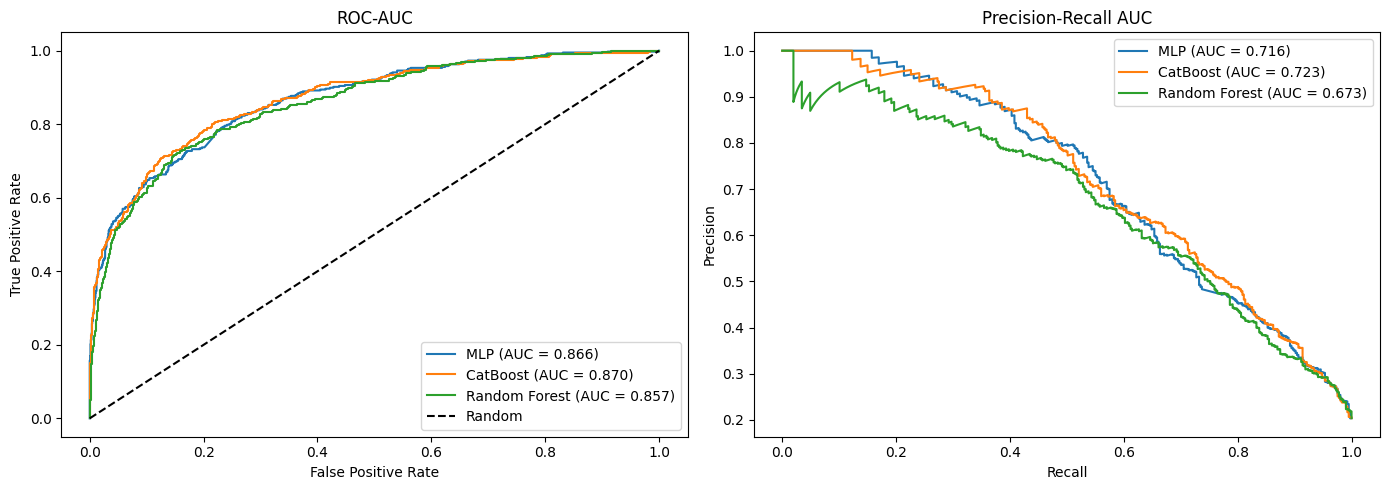

=== ROC-AUC ===
MLP: 0.8662
CatBoost: 0.8703
Random Forest: 0.8569

=== PR-AUC ===
MLP: 0.7160
CatBoost: 0.7226
Random Forest: 0.6734


In [248]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# Функция для расчёта и построения
def plot_curves(y_test, probs, model_name, ax_roc, ax_pr):
    # ROC-AUC
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = roc_auc_score(y_test, probs)
    ax_roc.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

    # PR-AUC
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    ax_pr.plot(recall, precision, label=f'{model_name} (AUC = {pr_auc:.3f})')

# Получаем вероятности для каждой модели
probs_mlp = model.predict_proba(X_test_scaled).flatten()
probs_cat = model_gb.predict_proba(X_test_np)[:, 1]
probs_rf = model_rf.predict_proba(X_test_np)[:, 1]

# Строим графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_curves(y_test_np, probs_mlp, 'MLP', ax1, ax2)
plot_curves(y_test_np, probs_cat, 'CatBoost', ax1, ax2)
plot_curves(y_test_np, probs_rf, 'Random Forest', ax1, ax2)

# Оформление ROC
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC-AUC')
ax1.legend()

# Оформление PR
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall AUC')
ax2.legend()

plt.tight_layout()
plt.show()

# Вывод численных значений
print("=== ROC-AUC ===")
print(f"MLP: {roc_auc_score(y_test_np, probs_mlp):.4f}")
print(f"CatBoost: {roc_auc_score(y_test_np, probs_cat):.4f}")
print(f"Random Forest: {roc_auc_score(y_test_np, probs_rf):.4f}")

print("\n=== PR-AUC ===")
print(f"MLP: {average_precision_score(y_test_np, probs_mlp):.4f}")
print(f"CatBoost: {average_precision_score(y_test_np, probs_cat):.4f}")
print(f"Random Forest: {average_precision_score(y_test_np, probs_rf):.4f}")

## Сравнение моделей


| Модель | ROC-AUC | PR-AUC    | Precision | Recall    | F1 |
|--------|---------|-----------|-----------|-----------|-----|
| **MLP** | 0.866 | 0.716     | 0.521     | **0.722** | 0.60 |
| **CatBoost** | **0.870** | **0.723** | **0.681** | 0.582     | **0.63** |
| **Random Forest** | 0.857 | 0.673     | 0.616     | 0.612     | 0.61 |

---

## Анализ результатов

### Что мы видим

1. **MLP лидирует по recall (0.726)**
   Модель находит **72% реальных ушедших клиентов** — это сильный результат для бизнеса, которому важно не упустить отток.

2. **CatBoost лучший по precision (0.681) и F1 (0.63)**
   Деревья реже ошибаются на лояльных клиентах, но находят только 58% ушедших.

3. **ROC-AUC у всех моделей близки (0.857–0.870)**
   Все модели отлично разделяют классы. Разница статистически незначима.

4. **PR-AUC > 0.71 у MLP и CatBoost**
   При дисбалансе 20% это **хороший результат** (случайная модель дала бы 0.20).

---

### Компромисс precision/recall

| Если важнее… | Какая модель лучше     | Рекомендуемый порог |
|--------------|------------------------|---------------------|
| …найти всех ушедших (recall) | **MLP** (0.726)        | 0.4–0.5 |
| …не беспокоить лояльных (precision) | **CatBoost** (0.681)   | 0.5–0.6 |
| …сбалансированный вариант | **CatBoost** (F1=0.63) | 0.5 |

---

### Можно ли улучшить MLP?

Да. Precision MLP (0.488) можно повысить:

- **Поднять порог** до 0.55–0.65 → precision вырастет до 0.60–0.70, recall упадёт до 0.60–0.70
- **Уменьшить Dropout** с 0.5 до 0.4 — модель станет увереннее
- **Уменьшить `pos_weight`** (сейчас 3.9 → попробовать 2.5–3.0)

---

## Вывод

**MLP показал результат, сопоставимый с градиентным бустингом:**

- ✅ ROC-AUC 0.866 (vs CatBoost 0.870)
- ✅ PR-AUC 0.714 (vs CatBoost 0.723)
- ✅ Лучший recall (0.776) — находит 4 из 5 ушедших клиентов

Невысокий precision (0.488) — это осознанный выбор в пользу полноты. При необходимости его легко повысить подбором порога или небольшим изменением архитектуры.

**Проект демонстрирует:**
- подготовку данных (нормализация, one-hot encoding, SMOTE)
- борьбу с дисбалансом (стратификация, pos_weight)
- построение и валидацию MLP на PyTorch
- сравнение с классическими методами ML